In [1]:
import dataset as ds
from dataset import TensorToImg, ImgWrite, ImgRead, ImgToTensor
dt = ds.Coco("/home/wanderer2414/coco2017/")

loading annotations into memory...
Done (t=7.98s)
creating index...
index created!
loading annotations into memory...
Done (t=0.08s)
creating index...
index created!


In [2]:
import MyRCNN
import torch
model = MyRCNN.Model(device=torch.device("cuda"))
model.train(dt)

[00:02:08] 8370.17578125                  ██████████████████████████████████████████████████████████ 50       /       50


In [14]:

from torch import stack
import torch
from torch import Tensor
def nms(boxes: Tensor)->Tensor:
    N = boxes.shape[0]
    rows, cols = torch.meshgrid(torch.arange(N, device=boxes.device), torch.arange(N, device=boxes.device), indexing='ij')
    
    boxes1 = boxes.unsqueeze(1).expand(N, N, 4)
    boxes2 = boxes.unsqueeze(0).expand(N, N, 4)
    x1 = torch.max(boxes1[:, :, 0], boxes2[:, :, 0])
    x2 = torch.min(boxes1[:, :, 2], boxes2[:, :, 2])
    w = x2 - x1
    del x1, x2
    y1 = torch.max(boxes1[:, :, 1], boxes2[:, :, 1])
    y2 = torch.min(boxes1[:, :, 3], boxes2[:, :, 3])
    h = y2-y1
    del y2, y1
    s = ((boxes[:, 2]-boxes[:, 0])*(boxes[:, 3] - boxes[:, 1]))
    s = s.unsqueeze(1).expand(N, N) + s.unsqueeze(0).expand(N, N)
    intersect = w*h
    IoU = intersect/(s - intersect)
    IoU = IoU * (rows>cols)
    cond = IoU > 0.8
    indices = (cond.any(dim=1).logical_not())
    
    return boxes[indices]

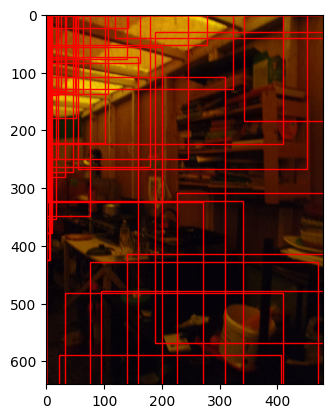

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as pat
from dataset import TensorToImg, ImgToTensor
x = dt.getTrainTensor(11).to(device=torch.device("cuda"))
mask, color, result = model.model(x)
boxes = result[1][:, :, 1:].squeeze(0)
boxes = nms(boxes)
for box in boxes:
    x1, y1, x2, y2 = box.detach().cpu().numpy()
    rect = pat.Rectangle((x1, y1), x2, y2, facecolor='none', edgecolor='red')
    plt.subplot().add_patch(rect)
# x = result[0]
# x = x.repeat(1, 3, 1, 1)
x = x-x.min()
x = x/x.max()
plt.imshow(TensorToImg(x.detach().cpu()))